# Implementación de la librería train_test_split de Sckit-learn

In [26]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
train = pd.read_csv("/content/train.csv")
train.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt,AdoptionSpeed
0,2,Nibble,3,299,0,1,1,7,0,1,...,1,1,100,41326,8480853f516546f6cf33aa88cd76c379,0,Nibble is a 3+ month old ball of cuteness. He ...,86e1089a3,1.0,2
1,2,No Name Yet,1,265,0,1,1,2,0,2,...,1,1,0,41401,3082c7125d8fb66f7dd4bff4192c8b14,0,I just found it alone yesterday near my apartm...,6296e909a,2.0,0
2,1,Brisco,1,307,0,1,2,7,0,2,...,1,1,0,41326,fa90fa5b1ee11c86938398b60abc32cb,0,Their pregnant mother was dumped by her irresp...,3422e4906,7.0,3
3,1,Miko,4,307,0,2,1,2,0,2,...,1,1,150,41401,9238e4f44c71a75282e62f7136c6b240,0,"Good guard dog, very alert, active, obedience ...",5842f1ff5,8.0,2
4,1,Hunter,1,307,0,1,1,0,0,2,...,1,1,0,41326,95481e953f8aed9ec3d16fc4509537e8,0,This handsome yet cute boy is up for adoption....,850a43f90,3.0,2


In [4]:
target_col = "AdoptionSpeed"

In [5]:
# 2. Separar variables (X) y etiqueta (y)
X = train.drop(columns=[target_col])
# Baseline solo con numéricas (rápido y sencillo)
X_num = X.select_dtypes(include=["number"])
#X = train.drop(columns=["AdoptionSpeed"])  # todas las columnas menos la etiqueta
y = train[target_col]               # etiqueta objetivo

In [18]:
# Agrupar clases de AdoptionSpeed en 3 niveles {target_antiguo:target_nuevo}
# 0 Adopción rápida
# 1 Adopción intermedia
# 2 No adoptado
y_grouped = y.replace({0: 0, 1: 0, 2: 1, 3: 1, 4: 2})

# Verificamos la nueva distribución
y_grouped.value_counts(normalize=True)

,proportion
AdoptionSpeed,
1,0.486627
2,0.279931
0,0.233442


Ahora las clases están más equilibradas.

In [19]:
# 3. Dividir en train y validación (por ejemplo, 80%-20%)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_num, y_grouped, test_size=0.2, random_state=42, stratify=y)

In [20]:
print(X_train.shape, X_valid.shape)

(11994, 19) (2999, 19)


In [21]:
# 4. Modelo
#Activar el balanceo automático - clase 0 minoritaria
model = LGBMClassifier(
    learning_rate=0.05,
    n_estimators=2000,
    random_state=42,
    class_weight='balanced'
)

In [22]:
# 5. Entrenar
# Entrenar con early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="multi_logloss",
    callbacks=[
        early_stopping(stopping_rounds=100),
        log_evaluation(100)
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 11994, number of used features: 19
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 0.986256
Early stopping, best iteration is:
[95]	valid_0's multi_logloss: 0.985887


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=2000,
               random_state=42)

In [23]:
# Predicciones sobre el conjunto de validación
y_pred = model.predict(X_valid)

# Evaluación
print("Accuracy:", accuracy_score(y_valid, y_pred))
print("F1-macro:", f1_score(y_valid, y_pred, average="macro"))

Accuracy: 0.4831610536845615
F1-macro: 0.48375443607531016


Con un accuracy de 0.48, el modelo mejoró su precisión, y ganó cobertura en lo dificil (clases raras, minoritarias)

In [24]:
#Reporte detallado por clase
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.36      0.57      0.44       700
           1       0.64      0.37      0.47      1459
           2       0.49      0.60      0.54       840

    accuracy                           0.48      2999
   macro avg       0.50      0.52      0.48      2999
weighted avg       0.53      0.48      0.48      2999



- 0: El modelo ahora detecta más del 50 % de las adopciones rápidas — antes casi no las veía.
- 1: Precisión buena, pero bajo recall: detecta pocas de las intermedias reales.
- 2: El mejor balance: reconoce bien a los no adoptados.

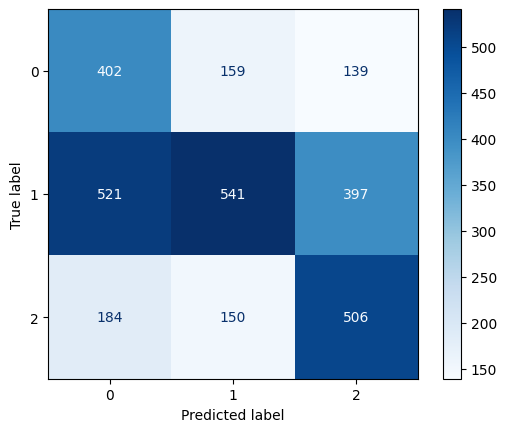

In [27]:
#Matriz de confusión
cm = confusion_matrix(y_valid, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

## Probemos el modelo

Objetivo: Agrupar clases. Reducir las 5 clases (0, 1, 2, 3, 4) a 3 niveles más balanceados, agrupando categorías similares:

In [28]:
# 7 PROBAR EL MODELO - REPETIR TODO EL PROCESO
# Cargar test.csv
test = pd.read_csv("/content/test.csv")
test.head()

,Type,Name,Age,Breed1,Breed2,Gender,Color1,Color2,Color3,MaturitySize,...,Sterilized,Health,Quantity,Fee,State,RescuerID,VideoAmt,Description,PetID,PhotoAmt
0,2,Dopey & Grey,8,266,266,1,2,6,7,1,...,2,1,2,0,41326,2ece3b2573dcdcebd774e635dca15fd9,0,"Dopey Age: 8mths old Male One half of a pair, ...",e2dfc2935,2.0
1,2,Chi Chi,36,285,264,2,1,4,7,2,...,1,2,1,0,41326,2ece3b2573dcdcebd774e635dca15fd9,0,"Please note that Chichi has been neutered, the...",f153b465f,1.0
2,2,Sticky,2,265,0,1,6,7,0,2,...,2,1,1,200,41326,e59c106e9912fa30c898976278c2e834,0,"Sticky, named such because of his tendency to ...",3c90f3f54,4.0
3,1,Dannie & Kass [In Penang],12,307,0,2,2,5,0,2,...,1,1,2,0,41326,e59c106e9912fa30c898976278c2e834,0,Dannie and Kass are mother and daughter. We en...,e02abc8a3,5.0
4,2,Cuddles,12,265,0,1,2,3,7,2,...,1,1,1,0,41326,e59c106e9912fa30c898976278c2e834,0,"Extremely cuddly cat, hence the origin of his ...",09f0df7d1,5.0


In [29]:
# Prepara el test
X_test = test.copy()

# Si quieres quedarte solo con variables numéricas (aunque LightGBM soporta categóricas)
X_test_num = X_test.select_dtypes(include=["number"])

# Predicción
y_pred = model.predict(X_test_num)

In [30]:
#submission.to_csv("submission.csv", index=False)
submission = pd.DataFrame({
    "PetID": test["PetID"],
    "AdoptionSpeed": y_pred
})

submission.to_csv("submission.csv", index=False)
print("Archivo 'submission.csv' generado correctamente ✅")
submission.head()

Archivo 'submission.csv' generado correctamente ✅


,PetID,AdoptionSpeed
0,e2dfc2935,2
1,f153b465f,0
2,3c90f3f54,0
3,e02abc8a3,2
4,09f0df7d1,2
